In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Dosyalar
F1 = "mental_health_and_technology_usage_2024.csv"
F2 = "Tech_Use_Stress_Wellness.csv"
F3 = "mental_health_social_media_dataset.csv"

sns.set()


In [2]:
def ensure_cols(df, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
    return out[cols]

def add_missingness_flags(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c + "_is_missing"] = df[c].isna().astype(int)
    return df

def pretty_print_columns(df, title="DATAFRAME"):
    print(f"\n================= 📌 {title} =================")
    print("Shape:", df.shape)
    print("Toplam sütun:", df.shape[1])

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
    flag_cols = [c for c in df.columns if c.endswith("_is_missing")]
    target_cols = [c for c in df.columns if c in ["target"]]

    def print_block(name, cols):
        print(f"\n🔹 {name} ({len(cols)})")
        if not cols:
            print("   • (yok)")
        else:
            for c in cols:
                print(f"   • {c}")

    print_block("NUMERİK SÜTUNLAR", numeric_cols)
    print_block("KATEGORİK SÜTUNLAR", categorical_cols)
    print_block("BOOLEAN SÜTUNLAR", bool_cols)
    print_block("MISSING FLAG SÜTUNLARI", flag_cols)
    print_block("TARGET SÜTUNLARI", target_cols)

    print("\n📋 Kolonlar (tek satır):")
    print(list(df.columns))
    print("================================================\n")


In [3]:
def analyze_feature_importance(df, target_col="mental_health_score", threshold=0.10):
    print(f"\n📊 ADIM 1: KORELASYON ANALİZİ VE SÜTUN ELEME MANTIĞI")
    print("-" * 60)

    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    if target_col not in corr_matrix.columns:
        print(f"⚠️ '{target_col}' bulunamadı. Korelasyon analizi atlandı.")
        return

    target_corr = corr_matrix[target_col].drop(target_col)

    print(f"{'DEĞİŞKEN':<30} | {'KORELASYON':<10} | {'KARAR'}")
    print("-" * 60)

    for col, val in target_corr.items():
        if col in ["stress_level", "weekly_depression_score", "weekly_anxiety_score", "mood_rating"]:
            decision = "⛔ ÇIKARILDI (Leakage riski)"
        elif col in ["phone_usage_hours", "laptop_usage_hours", "tv_usage_hours", "tablet_usage_hours"]:
            decision = "🔄 BİRLEŞTİRİLDİ (screen_time içine)"
        elif abs(val) >= threshold:
            decision = "✅ SEÇİLDİ (Güçlü ilişki)"
        else:
            decision = "⚠️ ZAYIF AMA TUTULUYOR"
        print(f"{col:<30} | {val:>8.4f}   | {decision}")

    print("-" * 60)
    print("NOT: 'stress_level' vb. değişkenler hedefe çok yakınsa modelin kopya çekmesine neden olabilir.\n")

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f")
    plt.title("Değişken İlişkileri (Heatmap)")
    plt.tight_layout()
    plt.show()


In [4]:
def build_merged_final(f1, f2, f3, run_analysis=True):
    print("Veri setleri yükleniyor ve ön işleme tabi tutuluyor...")

    # -----------------------------
    # (A) F2 geçici analiz + rename
    # -----------------------------
    df2_raw = pd.read_csv(f2)
    df2_temp = df2_raw.copy()

    # weekly -> daily hours (senin mantık)
    if "physical_activity_hours_per_week" in df2_temp.columns:
        df2_temp["activity"] = pd.to_numeric(df2_temp["physical_activity_hours_per_week"], errors="coerce") / 7

    print("\n🔄 SÜTUN DÖNÜŞÜMLERİ (F2):")
    print("   - 'daily_screen_time_hours' -> 'screen_time'")
    print("   - 'social_media_hours'      -> 'social_media'")
    print("   - 'gaming_hours'            -> 'gaming'")
    print("   - 'work_related_hours'      -> 'work_hours'")
    print("   - 'sleep_duration_hours'    -> 'sleep'")
    print("   - 'caffeine_intake_mg_per_day' -> 'caffeine'")

    df2_temp = df2_temp.rename(columns={
        "daily_screen_time_hours": "screen_time",
        "social_media_hours": "social_media",
        "gaming_hours": "gaming",
        "work_related_hours": "work_hours",
        "sleep_duration_hours": "sleep",
        "caffeine_intake_mg_per_day": "caffeine"
    })

    if run_analysis:
        analyze_feature_importance(df2_temp, target_col="mental_health_score", threshold=0.10)

    # -----------------------------
    # (B) Sabit şablon (senin FIXED_TARGET_COLS)
    # -----------------------------
    FIXED_TARGET_COLS = [
        "age", "gender", "screen_time", "social_media", "gaming", "work_hours",
        "sleep", "activity", "caffeine", "support", "platform", "source",
        "label_available", "negative_interactions_count", "positive_interactions_count",
        "mental_health_score"
    ]

    print("\n📝 ADIM 2: FINAL SÜTUN ŞABLONU")
    print(f"-> ({len(FIXED_TARGET_COLS)} adet) {FIXED_TARGET_COLS}")

    # -----------------------------
    # (C) DF1 standardizasyon
    # -----------------------------
    df1 = pd.read_csv(f1)
    df1_sel = df1.rename(columns={
        "Age": "age",
        "Gender": "gender",
        "Screen_Time_Hours": "screen_time",
        "Social_Media_Usage_Hours": "social_media",
        "Gaming_Hours": "gaming",
        "Sleep_Hours": "sleep",
        "Physical_Activity_Hours": "activity",
        "Support_Systems_Access": "support"
    })
    df1_sel["source"] = "df1"
    df1_sel["label_available"] = 0

    # -----------------------------
    # (D) DF2 standardizasyon (etiketli)
    # -----------------------------
    df2 = pd.read_csv(f2)
    if "physical_activity_hours_per_week" in df2.columns:
        df2["activity"] = pd.to_numeric(df2["physical_activity_hours_per_week"], errors="coerce") / 7

    df2_sel = df2.rename(columns={
        "age": "age",
        "gender": "gender",
        "daily_screen_time_hours": "screen_time",
        "social_media_hours": "social_media",
        "gaming_hours": "gaming",
        "work_related_hours": "work_hours",
        "sleep_duration_hours": "sleep",
        "caffeine_intake_mg_per_day": "caffeine",
        "mental_health_score": "mental_health_score"
    })
    df2_sel["source"] = "df2"
    df2_sel["label_available"] = 1

    # -----------------------------
    # (E) DF3 standardizasyon
    # -----------------------------
    df3 = pd.read_csv(f3)

    # dakika -> saat dönüşümleri
    if "daily_screen_time_min" in df3.columns:
        df3["screen_time"] = pd.to_numeric(df3["daily_screen_time_min"], errors="coerce") / 60
    if "social_media_time_min" in df3.columns:
        df3["social_media"] = pd.to_numeric(df3["social_media_time_min"], errors="coerce") / 60
    if "sleep_hours" in df3.columns:
        df3["sleep"] = pd.to_numeric(df3["sleep_hours"], errors="coerce")
    if "physical_activity_min" in df3.columns:
        df3["activity"] = pd.to_numeric(df3["physical_activity_min"], errors="coerce") / 60

    df3_sel = df3.rename(columns={
        "platform": "platform",
        "negative_interactions_count": "negative_interactions_count",
        "positive_interactions_count": "positive_interactions_count"
    })
    df3_sel["source"] = "df3"
    df3_sel["label_available"] = 0

    # -----------------------------
    # (F) Şablona uydur + concat
    # -----------------------------
    df1_final = ensure_cols(df1_sel, FIXED_TARGET_COLS)
    df2_final = ensure_cols(df2_sel, FIXED_TARGET_COLS)
    df3_final = ensure_cols(df3_sel, FIXED_TARGET_COLS)

    merged = pd.concat([df1_final, df2_final, df3_final], ignore_index=True)

    # -----------------------------
    # (G) Temizlik (senin mantık)
    # -----------------------------
    merged["gender"] = merged["gender"].astype(str).str.strip().str.title()
    merged["gender"] = (
        merged["gender"]
        .replace({"Man":"Male","Woman":"Female","Erkek":"Male","Kadın":"Female","Nan":"Unknown"})
        .replace("Unknown", np.nan)
        .fillna("Unknown")
    )

    merged["support"] = merged["support"].fillna("Unknown")
    merged["platform"] = merged["platform"].fillna("Unknown")

    return merged


Veri setleri yükleniyor ve ön işleme tabi tutuluyor...

🔄 SÜTUN DÖNÜŞÜMLERİ (F2):
   - 'daily_screen_time_hours' -> 'screen_time'
   - 'social_media_hours'      -> 'social_media'
   - 'gaming_hours'            -> 'gaming'
   - 'work_related_hours'      -> 'work_hours'
   - 'sleep_duration_hours'    -> 'sleep'
   - 'caffeine_intake_mg_per_day' -> 'caffeine'

📊 ADIM 1: KORELASYON ANALİZİ VE SÜTUN ELEME MANTIĞI
------------------------------------------------------------
DEĞİŞKEN                       | KORELASYON | KARAR
------------------------------------------------------------
user_id                        |  -0.0010   | ⚠️ ZAYIF AMA TUTULUYOR
age                            |   0.3732   | ✅ SEÇİLDİ (Güçlü ilişki)
screen_time                    |  -0.6218   | ✅ SEÇİLDİ (Güçlü ilişki)
phone_usage_hours              |  -0.2662   | 🔄 BİRLEŞTİRİLDİ (screen_time içine)
laptop_usage_hours             |  -0.2869   | 🔄 BİRLEŞTİRİLDİ (screen_time içine)
tablet_usage_hours             |  -0.16

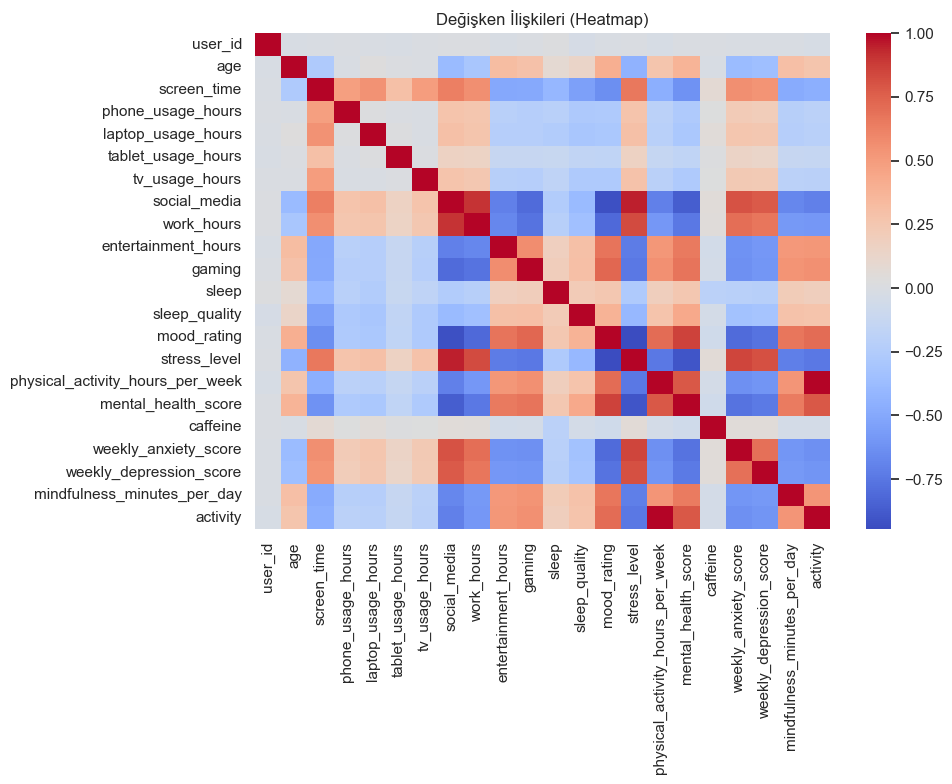


📝 ADIM 2: FINAL SÜTUN ŞABLONU
-> (16 adet) ['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activity', 'caffeine', 'support', 'platform', 'source', 'label_available', 'negative_interactions_count', 'positive_interactions_count', 'mental_health_score']

✅ İŞLEM TAMAMLANDI!
Sonuç shape: (20000, 16)


,age,gender,screen_time,social_media,gaming,work_hours,sleep,activity,caffeine,support,platform,source,label_available,negative_interactions_count,positive_interactions_count,mental_health_score
0,23,Female,12.36,6.00,0.68,NaN,8.01,6.71,NaN,No,Unknown,df1,0,NaN,NaN,NaN
1,21,Male,7.61,2.57,3.74,NaN,7.28,5.88,NaN,Yes,Unknown,df1,0,NaN,NaN,NaN
2,51,Male,3.16,6.14,1.26,NaN,8.04,9.81,NaN,No,Unknown,df1,0,NaN,NaN,NaN
3,25,Female,13.08,4.48,2.59,NaN,5.62,5.28,NaN,Yes,Unknown,df1,0,NaN,NaN,NaN
4,53,Male,12.63,0.56,0.29,NaN,5.55,4.00,NaN,No,Unknown,df1,0,NaN,NaN,NaN


In [5]:
merged = build_merged_final(F1, F2, F3, run_analysis=True)

print("\n✅ İŞLEM TAMAMLANDI!")
print("Sonuç shape:", merged.shape)
display(merged.head())


In [6]:
FLAG_COLS = ["work_hours","caffeine","negative_interactions_count","positive_interactions_count","mental_health_score"]

merged2 = add_missingness_flags(merged, FLAG_COLS)

pretty_print_columns(merged2, title="merged2 (flag eklenmiş)")



================= 📌 merged2 (flag eklenmiş) =================
Shape: (20000, 21)
Toplam sütun: 21

🔹 NUMERİK SÜTUNLAR (17)
   • age
   • screen_time
   • social_media
   • gaming
   • work_hours
   • sleep
   • activity
   • caffeine
   • label_available
   • negative_interactions_count
   • positive_interactions_count
   • mental_health_score
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 KATEGORİK SÜTUNLAR (4)
   • gender
   • support
   • platform
   • source

🔹 BOOLEAN SÜTUNLAR (0)
   • (yok)

🔹 MISSING FLAG SÜTUNLARI (5)
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 TARGET SÜTUNLARI (0)
   • (yok)

📋 Kolonlar (tek satır):
['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activity', 'caff

In [7]:
df_labeled = merged2[merged2["label_available"] == 1].copy()
print("df_labeled shape:", df_labeled.shape)


df_labeled shape: (5000, 21)


In [8]:
score = pd.to_numeric(df_labeled["mental_health_score"], errors="coerce")
score = score.fillna(score.median())

thr = score.median()
df_labeled["target"] = (score < thr).astype(int)

print(df_labeled["target"].value_counts(normalize=True))


target
0    0.5028
1    0.4972
Name: proportion, dtype: float64


In [9]:
DROP_FOR_MODEL = ["target", "mental_health_score"]  # en kritik ikisi
# İstersen bunları da düşünebilirsin:
# DROP_FOR_MODEL += ["label_available"]  # label var/yok bilgisi modele gereksiz
# DROP_FOR_MODEL += ["source"]           # domain-bias yapabilir
# DROP_FOR_MODEL += ["mental_health_score_is_missing"]  # target’a dolaylı sinyal olabilir

X = df_labeled.drop(columns=[c for c in DROP_FOR_MODEL if c in df_labeled.columns])
y = df_labeled["target"].copy()

print("X shape:", X.shape, "y shape:", y.shape)
pretty_print_columns(X, title="X (Model Feature Set)")


X shape: (5000, 20) y shape: (5000,)

================= 📌 X (Model Feature Set) =================
Shape: (5000, 20)
Toplam sütun: 20

🔹 NUMERİK SÜTUNLAR (16)
   • age
   • screen_time
   • social_media
   • gaming
   • work_hours
   • sleep
   • activity
   • caffeine
   • label_available
   • negative_interactions_count
   • positive_interactions_count
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 KATEGORİK SÜTUNLAR (4)
   • gender
   • support
   • platform
   • source

🔹 BOOLEAN SÜTUNLAR (0)
   • (yok)

🔹 MISSING FLAG SÜTUNLARI (5)
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 TARGET SÜTUNLARI (0)
   • (yok)

📋 Kolonlar (tek satır):
['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activit

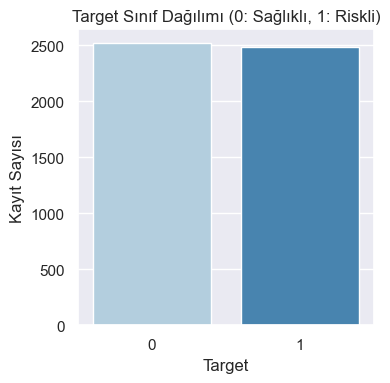

In [10]:
plt.figure(figsize=(4,4))
sns.countplot(x="target", data=df_labeled, palette="Blues")
plt.title("Target Sınıf Dağılımı (0: Sağlıklı, 1: Riskli)")
plt.xlabel("Target")
plt.ylabel("Kayıt Sayısı")
plt.tight_layout()
plt.show()


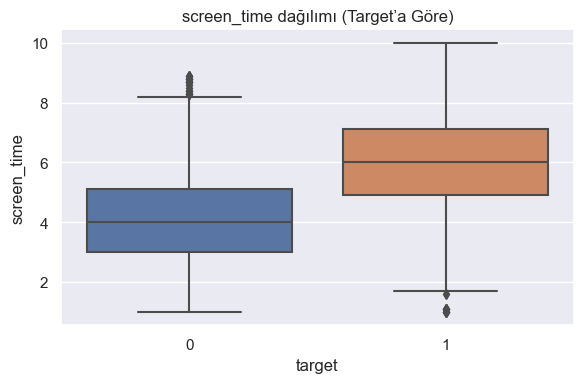

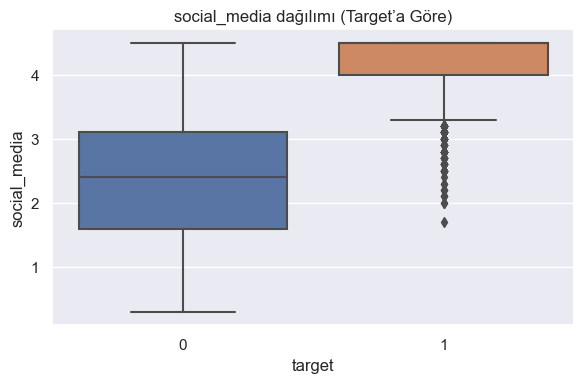

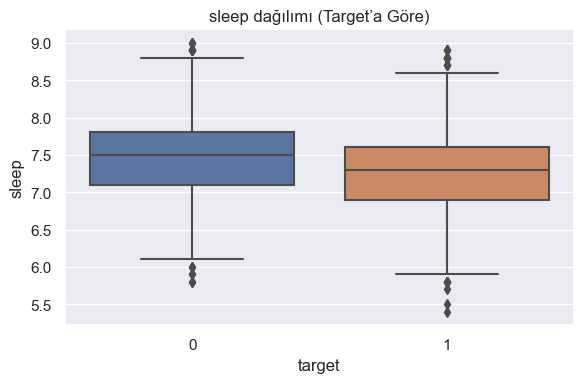

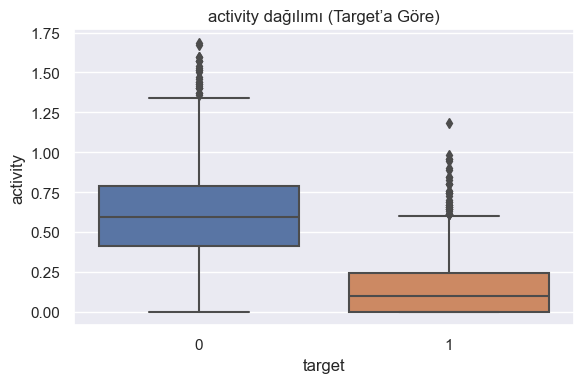

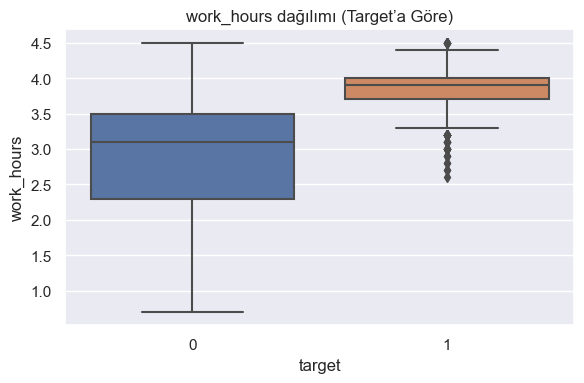

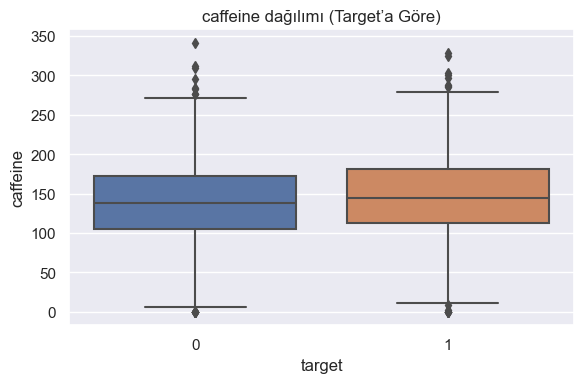

In [11]:
num_viz_cols = ["screen_time", "social_media", "sleep", "activity", "work_hours", "caffeine"]

for col in num_viz_cols:
    if col in df_labeled.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x="target", y=col, data=df_labeled)
        plt.title(f"{col} dağılımı (Target’a Göre)")
        plt.tight_layout()
        plt.show()


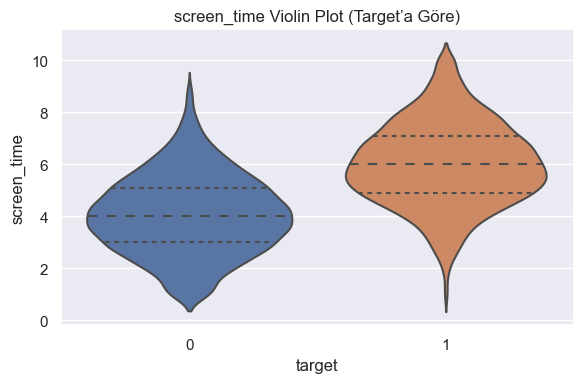

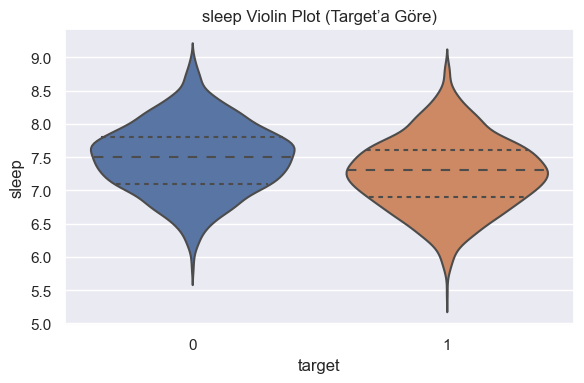

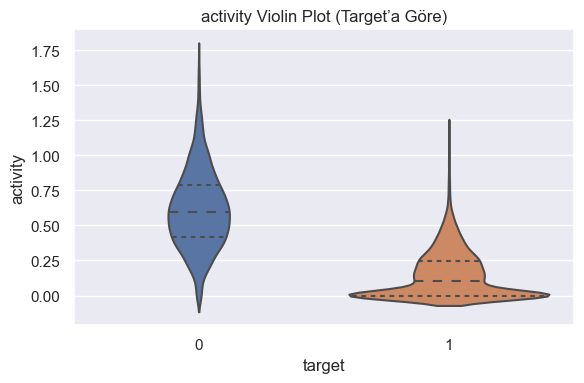

In [12]:
for col in ["screen_time", "sleep", "activity"]:
    if col in df_labeled.columns:
        plt.figure(figsize=(6,4))
        sns.violinplot(x="target", y=col, data=df_labeled, inner="quartile")
        plt.title(f"{col} Violin Plot (Target’a Göre)")
        plt.tight_layout()
        plt.show()


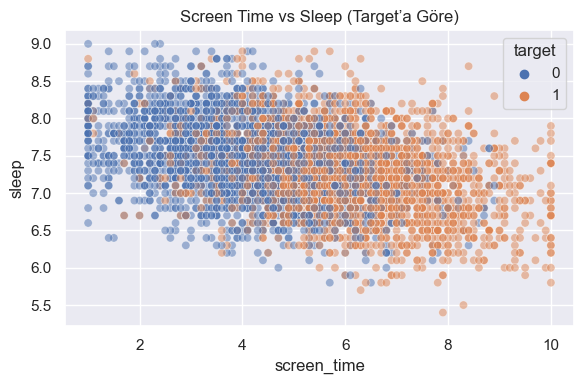

In [13]:
if "screen_time" in df_labeled.columns and "sleep" in df_labeled.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df_labeled, x="screen_time", y="sleep", hue="target", alpha=0.5)
    plt.title("Screen Time vs Sleep (Target’a Göre)")
    plt.tight_layout()
    plt.show()


In [14]:
TARGET_COL = "target"

LEAKAGE_COLS = [
    "mental_health_score",
    "mental_health_score_is_missing",   # <<< EKLE
    "label_available",
    "source"
]
def select_numeric_features_by_corr(df, target_col="target", threshold=0.10):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    numeric_cols = [c for c in numeric_cols if c != target_col]

    # 1) tamamen NaN olanları at
    numeric_cols = [c for c in numeric_cols if df[c].notna().any()]

    # 2) constant (std=0) olanları at
    numeric_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]

    corr = df[numeric_cols].corrwith(df[target_col]).abs()
    corr = corr.dropna()

    selected = corr[corr >= threshold].sort_values(ascending=False)

    print("\n📊 SAYISAL FEATURE SEÇİMİ (Pearson |target|):")
    for col, val in selected.items():
        print(f" ✅ {col:<35} | corr = {val:.3f}")

    return selected.index.tolist()

def select_categorical_features_by_cramersv(
    df,
    target_col="target",
    threshold=0.10
):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    selected = []

    print("\n📊 KATEGORİK FEATURE SEÇİMİ (Cramér’s V):")

    for col in cat_cols:
        v = _cramers_v(df[col], df[target_col])
        if pd.notna(v) and v >= threshold:
            selected.append(col)
            print(f" ✅ {col:<35} | V = {v:.3f}")
        else:
            print(f" ❌ {col:<35} | V = {v:.3f}")

    return selected
def get_missingness_flags(df):
    return [c for c in df.columns if c.endswith("_is_missing")]
def auto_select_features(
    df,
    target_col="target",
    corr_threshold=0.10,
    cramers_threshold=0.10
):
    num_feats = select_numeric_features_by_corr(
        df,
        target_col=target_col,
        threshold=corr_threshold
    )

    cat_feats = select_categorical_features_by_cramersv(
        df,
        target_col=target_col,
        threshold=cramers_threshold
    )

    flag_feats = get_missingness_flags(df)

    # Leakage ve target temizliği
    all_feats = (
        set(num_feats)
        | set(cat_feats)
        | set(flag_feats)
    )

    all_feats = [
        c for c in all_feats
        if c not in LEAKAGE_COLS
        and c != target_col
    ]

    print("\n🎯 OTOMATİK SEÇİLEN FEATURE SETİ:")
    print(all_feats)
    print(f"Toplam feature sayısı: {len(all_feats)}")

    return all_feats


In [15]:
import numpy as np
import pandas as pd

def _cramers_v(x, y):
    """
    Cramér's V hesaplar (kategorik-kategorik ilişki gücü).
    Target ikili (0/1) olduğunda da güvenle çalışır.
    """
    conf = pd.crosstab(x, y)

    if conf.size == 0:
        return np.nan

    n = conf.to_numpy().sum()
    if n == 0:
        return np.nan

    obs = conf.to_numpy()

    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / n

    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - expected) ** 2 / expected)

    r, k = conf.shape
    phi2 = chi2 / n

    # Bias correction (çok önemli)
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1)) if n > 1 else 0
    rcorr = r - ((r - 1)**2) / (n - 1) if n > 1 else r
    kcorr = k - ((k - 1)**2) / (n - 1) if n > 1 else k

    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


In [16]:
FEATURE_COLS = auto_select_features(
    df_labeled,
    target_col="target",
    corr_threshold=0.10,
    cramers_threshold=0.10
)


# flags'leri her zaman katmak istersen:
force_flags = [
    "work_hours_is_missing",
    "caffeine_is_missing",
    "negative_interactions_count_is_missing",
    "positive_interactions_count_is_missing"
]
for f in force_flags:
    if f in df_labeled.columns:
        FEATURE_COLS.append(f)

# leakage temizliği + target dışla + df'de var olanları bırak
FEATURE_COLS = sorted(set([c for c in FEATURE_COLS
                           if c in df_labeled.columns
                           and c != "target"
                           and c not in LEAKAGE_COLS]))

print("✅ Final FEATURE_COLS:", FEATURE_COLS)
print("Toplam feature:", len(FEATURE_COLS))




📊 SAYISAL FEATURE SEÇİMİ (Pearson |target|):
 ✅ mental_health_score                 | corr = 0.847
 ✅ social_media                        | corr = 0.771
 ✅ activity                            | corr = 0.712
 ✅ work_hours                          | corr = 0.621
 ✅ gaming                              | corr = 0.604
 ✅ screen_time                         | corr = 0.531
 ✅ age                                 | corr = 0.327
 ✅ sleep                               | corr = 0.217

📊 KATEGORİK FEATURE SEÇİMİ (Cramér’s V):
 ❌ gender                              | V = 0.007
 ❌ support                             | V = nan
 ❌ platform                            | V = nan
 ❌ source                              | V = nan

🎯 OTOMATİK SEÇİLEN FEATURE SETİ:
['work_hours_is_missing', 'activity', 'negative_interactions_count_is_missing', 'work_hours', 'caffeine_is_missing', 'positive_interactions_count_is_missing', 'sleep', 'age', 'gaming', 'screen_time', 'social_media']
Toplam feature sayısı: 11
✅ Fina

In [17]:

# =========================================================
# 2) X / y
# =========================================================
X = df_labeled[FEATURE_COLS].copy()
y = df_labeled["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5000, 11)
y shape: (5000,)


In [18]:
from sklearn.model_selection import train_test_split

# =========================================================
# 3) Train/Test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.semi_supervised import SelfTrainingClassifier

# (Opsiyonel) SMOTE için
USE_SMOTE = True
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except:
    USE_SMOTE = False

sns.set()

# =========================================================
# 6) Modeller
# =========================================================
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "RF": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "HGB": HistGradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, class_weight="balanced")
}

param_dists = {
    "LogReg": {"model__C": np.logspace(-2, 1, 20)},
    "RF": {
        "model__n_estimators": [200, 400, 700],
        "model__max_depth": [None, 6, 10, 14],
        "model__min_samples_leaf": [1, 5, 10, 20],
    },
    "HGB": {
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 5, 7, None],
        "model__max_iter": [200, 400, 800],
    },
    "SVC": {
        "model__C": np.logspace(-1, 2, 20),
        "model__gamma": ["scale","auto"]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# -------------------------------------------------
# 0) Feature set (sende hazırsa kullan)
#    Eğer FEATURE_COLS yoksa, en azından şunu yap:
# -------------------------------------------------
assert "df_labeled" in globals(), "❌ df_labeled yok. Önce df_labeled üret."
assert "target" in df_labeled.columns, "❌ target yok. Önce target üret."

# Leakage-safe: target'tan türeyen score'u (ve flag'ini) modele sokma
LEAKAGE = ["mental_health_score", "mental_health_score_is_missing", "label_available"]
for c in LEAKAGE:
    if c in df_labeled.columns and c in FEATURE_COLS:
        FEATURE_COLS = [x for x in FEATURE_COLS if x != c]

# X / y
X = df_labeled[FEATURE_COLS].copy()
y = df_labeled["target"].values

print("X shape:", X.shape, "| y shape:", y.shape)

# -------------------------------------------------
# 1) Split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------
# 2) 0 -> NaN + Winsorize (senin mantık, burada tanımlıyoruz)
# -------------------------------------------------
ZERO_AS_MISSING = ["screen_time","social_media","sleep","activity"]
def zero_to_nan(df_in):
    df_out = df_in.copy()
    for c in ZERO_AS_MISSING:
        if c in df_out.columns:
            s = pd.to_numeric(df_out[c], errors="coerce")
            df_out.loc[s == 0, c] = np.nan
    return df_out

WINS_COLS = ["age","screen_time","social_media","gaming","work_hours","sleep","activity","caffeine",
             "negative_interactions_count","positive_interactions_count"]
def winsorize_df(df_in, low=0.01, high=0.99):
    df_out = df_in.copy()
    for c in WINS_COLS:
        if c in df_out.columns:
            s = pd.to_numeric(df_out[c], errors="coerce")
            if s.notna().sum() == 0:
                continue
            lo, hi = s.quantile(low), s.quantile(high)
            df_out[c] = s.clip(lo, hi)
    return df_out

pre_df = Pipeline(steps=[
    ("zero_to_nan", FunctionTransformer(zero_to_nan, feature_names_out="one-to-one")),
    ("winsor", FunctionTransformer(winsorize_df, feature_names_out="one-to-one")),
])

# -------------------------------------------------
# 3) Preprocess: num + cat
# -------------------------------------------------
num_selector = make_column_selector(dtype_include=np.number)
cat_selector = make_column_selector(dtype_exclude=np.number)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_selector),
        ("cat", categorical_pipe, cat_selector),
    ],
    remainder="drop"
)

print("✅ pre_df ve preprocess hazır. Split hazır.")


X shape: (5000, 11) | y shape: (5000,)
✅ pre_df ve preprocess hazır. Split hazır.


In [21]:
preprocess.fit(X_train)
FEATURE_NAMES = preprocess.get_feature_names_out()

print("🎯 Toplam feature sayısı:", len(FEATURE_NAMES))
print("🧱 İlk 50 feature:")
print(FEATURE_NAMES[:50])
for f in FEATURE_NAMES:
    print(f)


🎯 Toplam feature sayısı: 11
🧱 İlk 50 feature:
['num__activity' 'num__age' 'num__caffeine_is_missing' 'num__gaming'
 'num__negative_interactions_count_is_missing'
 'num__positive_interactions_count_is_missing' 'num__screen_time'
 'num__sleep' 'num__social_media' 'num__work_hours'
 'num__work_hours_is_missing']
num__activity
num__age
num__caffeine_is_missing
num__gaming
num__negative_interactions_count_is_missing
num__positive_interactions_count_is_missing
num__screen_time
num__sleep
num__social_media
num__work_hours
num__work_hours_is_missing


In [22]:
best_models = {}
for name, est in models.items():
    pipe = Pipeline(steps=[
        ("pre_df", pre_df),
        ("prep", preprocess),
        ("model", est)
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dists[name],
        n_iter=15,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    print("\n===", name, "===")
    print("Best CV f1_macro:", search.best_score_)
    print("Best params:", search.best_params_)



=== LogReg ===
Best CV f1_macro: 0.9004594928632796
Best params: {'model__C': 1.1288378916846884}

=== RF ===
Best CV f1_macro: 0.9039938819227261
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 6}

=== HGB ===
Best CV f1_macro: 0.9052408224343134
Best params: {'model__max_iter': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05}

=== SVC ===
Best CV f1_macro: 0.9022393660398127
Best params: {'model__gamma': 'scale', 'model__C': 1.8329807108324356}


In [23]:
# ===============================
# DEBUG + TRAINING + RESULTS
# ===============================
import time
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

print("🔍 DEBUG")
print("models var mı? ->", bool(models))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

results = []
best_models = {}

for name, est in models.items():
    print(f"\n🚀 MODEL BAŞLIYOR: {name}")

    pipe = Pipeline(steps=[
        ("pre_df", pre_df),
        ("prep", preprocess),
        ("model", est)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dists[name],
        n_iter=15,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )

    t0 = time.time()
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print("❌ FIT HATASI:", e)
        continue

    fit_time = time.time() - t0

    best_models[name] = search.best_estimator_

    y_pred_train = search.best_estimator_.predict(X_train)
    y_pred_test  = search.best_estimator_.predict(X_test)

    results.append({
        "Model": name,
        "Best_CV_F1": round(search.best_score_, 4),
        "Train_F1": round(f1_score(y_train, y_pred_train, average="macro"), 4),
        "Test_F1": round(f1_score(y_test, y_pred_test, average="macro"), 4),
        "Train_Acc": round(accuracy_score(y_train, y_pred_train), 4),
        "Test_Acc": round(accuracy_score(y_test, y_pred_test), 4),
        "Fit_Time_sec": round(fit_time, 2),
        "Best_Params": search.best_params_
    })

    print("✅ BİTTİ:", name)

# ===============================
# SONUÇ TABLOSU
# ===============================
if len(results) == 0:
    raise RuntimeError("❌ HİÇ MODEL EĞİTİLMEDİ. Yukarıdaki debug çıktısına bak.")

results_df = pd.DataFrame(results).sort_values("Test_F1", ascending=False).reset_index(drop=True)

print("\n🏁 SONUÇ TABLOSU")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("\n🏆 EN İYİ MODEL:", best_model_name)


🔍 DEBUG
models var mı? -> True
X_train shape: (4000, 11)
y_train shape: (4000,)

🚀 MODEL BAŞLIYOR: LogReg
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: LogReg

🚀 MODEL BAŞLIYOR: RF
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: RF

🚀 MODEL BAŞLIYOR: HGB
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: HGB

🚀 MODEL BAŞLIYOR: SVC
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: SVC

🏁 SONUÇ TABLOSU


,Model,Best_CV_F1,Train_F1,Test_F1,Train_Acc,Test_Acc,Fit_Time_sec,Best_Params
0,HGB,0.9052,0.9162,0.912,0.9162,0.912,584.96,"{'model__max_iter': 200, 'model__max_depth': 3..."
1,LogReg,0.9005,0.8995,0.910,0.8995,0.910,55.60,{'model__C': 1.1288378916846884}
2,SVC,0.9022,0.9102,0.905,0.9102,0.905,642.43,"{'model__gamma': 'scale', 'model__C': 1.832980..."
3,RF,0.9040,0.9197,0.904,0.9198,0.904,469.43,"{'model__n_estimators': 200, 'model__min_sampl..."



🏆 EN İYİ MODEL: HGB


In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, classification_report, brier_score_loss
)
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.calibration import calibration_curve


# =========================================================
# Helpers
# =========================================================
def get_estimator_name(model):
    """Pipeline ise içindeki son estimator adını döndürür."""
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        return model.named_steps["model"].__class__.__name__
    return model.__class__.__name__


def get_proba(model, X):
    """
    Binary ROC/Calibration için olasılık üretir.
    - predict_proba varsa onu kullanır
    - yoksa decision_function -> sigmoid approx
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise ValueError("Model predict_proba veya decision_function desteklemiyor.")


# =========================================================
# Plots
# =========================================================
def plot_confusion_matrices(y_true, y_pred, name="MODEL"):
    labels = np.unique(y_true)

    # Count
    cm_count = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm_count, display_labels=labels).plot(values_format="d")
    plt.title(f"{name} – Confusion Matrix (Count)")
    plt.tight_layout()
    plt.show()

    # Normalized (row-wise)
    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(values_format=".2f")
    plt.title(f"{name} – Confusion Matrix (Normalized)")
    plt.tight_layout()
    plt.show()


def plot_calibration_curve_binary(model, X_test, y_test, name="MODEL", n_bins=10, strategy="quantile"):
    classes = np.unique(y_test)
    if len(classes) != 2:
        print(f"❗ {name}: Calibration curve sadece binary için. Sınıf sayısı={len(classes)}")
        return

    y_prob = get_proba(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy=strategy)

    auc = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot([0,1], [0,1], "--", label="Perfect")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=f"{name} (Brier={brier:.4f}, AUC={auc:.3f})")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(f"{name} – Calibration Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"⚠️ Calibration: AUC={auc:.3f} | Brier={brier:.4f} (↓ daha iyi)")


def roc_overfit_report_binary(model, X_train, y_train, X_test, y_test, name="MODEL"):
    classes = np.unique(y_test)
    if len(classes) != 2:
        print(f"❗ {name}: ROC sadece binary için. Sınıf sayısı={len(classes)}")
        return

    # ROC
    y_prob = get_proba(model, X_test)
    auc = roc_auc_score(y_test, y_prob)

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{name} – ROC Curve (AUC={auc:.3f})")
    plt.tight_layout()
    plt.show()

    # Overfit (Train vs Test)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test  = f1_score(y_test,  y_pred_test,  average="macro")

    gap = f1_train - f1_test
    print("⚠️ Overfitting Analizi (F1-macro)")
    print(f"Train F1-macro: {f1_train:.4f}")
    print(f"Test  F1-macro: {f1_test:.4f}")
    print(f"Fark (Train-Test): {gap:.4f}")

    if gap > 0.05:
        print("📌 Yorum: Overfitting eğilimi VAR\n")
    else:
        print("📌 Yorum: Belirgin overfitting YOK\n")


# =========================================================
# Main evaluation (all-in-one)
# =========================================================
def evaluate_full_clean(model, X_train, y_train, X_test, y_test, name=None):
    if name is None:
        name = get_estimator_name(model)

    print("\n========================================")
    print(f"📌 MODEL: {name}")
    print("========================================")

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # Metrics
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test  = f1_score(y_test,  y_pred_test,  average="macro")

    print(f"✅ Train Accuracy : {acc_train:.4f} | Test Accuracy : {acc_test:.4f}")
    print(f"✅ Train F1-macro : {f1_train:.4f} | Test F1-macro : {f1_test:.4f}")

    # Binary precision/recall
    classes = np.unique(y_test)
    if len(classes) == 2:
        prec = precision_score(y_test, y_pred_test, zero_division=0)
        rec  = recall_score(y_test, y_pred_test, zero_division=0)
        print(f"✅ Test Precision : {prec:.4f} | Test Recall : {rec:.4f}")

    print("\n📄 Classification Report (Test):")
    print(classification_report(y_test, y_pred_test))

    # Confusion matrices
    plot_confusion_matrices(y_test, y_pred_test, name=name)

    # ROC + Calibration (binary)
    if len(classes) == 2:
        roc_overfit_report_binary(model, X_train, y_train, X_test, y_test, name=name)
        plot_calibration_curve_binary(model, X_test, y_test, name=name)

    # Learning curve
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, marker="o", label="Train F1-macro")
    plt.plot(train_sizes, val_mean, marker="o", label="CV F1-macro")
    plt.title(f"{name} – Learning Curve (F1-macro)")
    plt.xlabel("Training samples")
    plt.ylabel("F1-macro")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("========================================\n")




📌 MODEL: HGB (HistGradientBoostingClassifier)
✅ Train Accuracy : 0.9163 | Test Accuracy : 0.9120
✅ Train F1-macro : 0.9162 | Test F1-macro : 0.9120
✅ Test Precision : 0.9148 | Test Recall : 0.9074

📄 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       503
           1       0.91      0.91      0.91       497

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



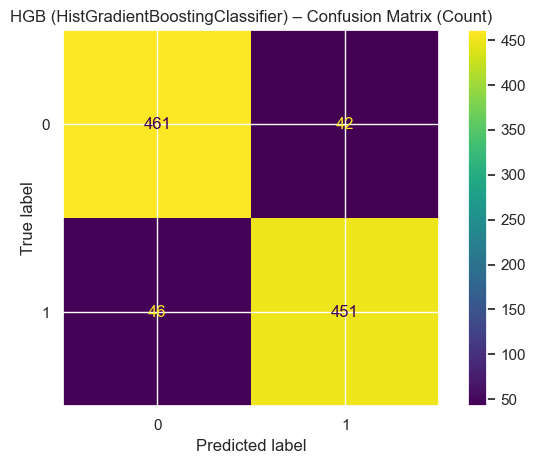

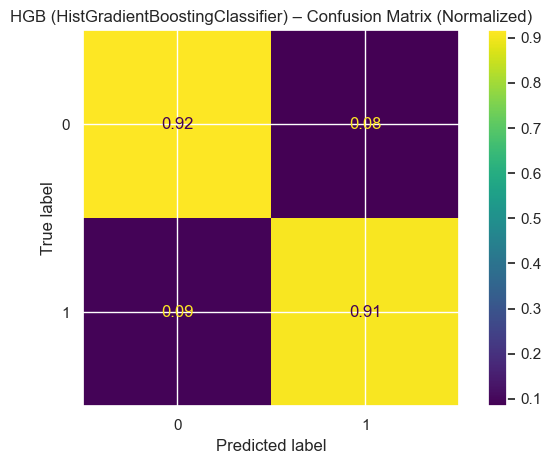

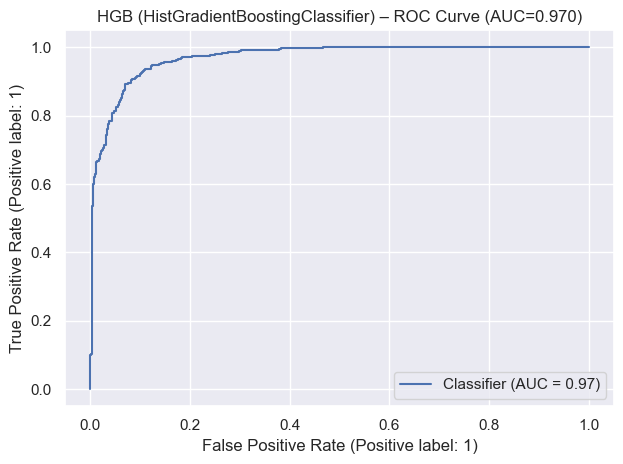

⚠️ Overfitting Analizi (F1-macro)
Train F1-macro: 0.9162
Test  F1-macro: 0.9120
Fark (Train-Test): 0.0043
📌 Yorum: Belirgin overfitting YOK



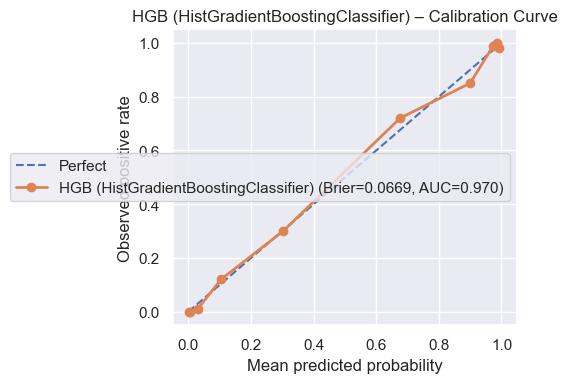

⚠️ Calibration: AUC=0.970 | Brier=0.0669 (↓ daha iyi)


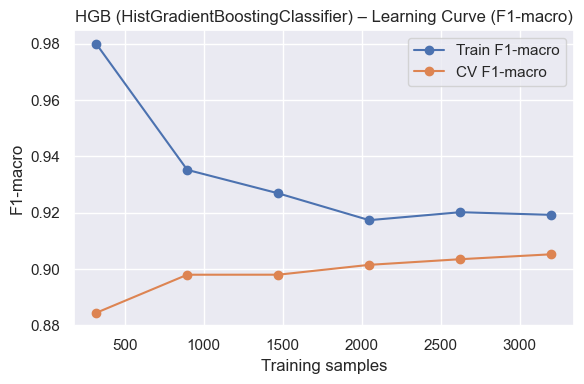

In [25]:

# =========================================================
# RUN for best HGB
# =========================================================
best_model = best_models["HGB"]          # senin sözlüğünden geliyor
best_name  = "HGB (HistGradientBoostingClassifier)"

evaluate_full_clean(best_model, X_train, y_train, X_test, y_test, name=best_name)


In [26]:
import joblib
from datetime import datetime
from pathlib import Path

# -------------------------------------------------
# BEST MODEL
# -------------------------------------------------
best_model = best_models["HGB"]

# -------------------------------------------------
# KLASÖR (yoksa oluştur)
# -------------------------------------------------
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# DOSYA ADI (tez / sunum uyumlu)
# -------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"best_model_HGB_pipeline_{timestamp}.joblib"
model_path = models_dir / model_filename

# -------------------------------------------------
# KAYDET
# -------------------------------------------------
joblib.dump(best_model, model_path)

print(f"✅ BEST MODEL (HGB) başarıyla kaydedildi → {model_path}")


✅ BEST MODEL (HGB) başarıyla kaydedildi → models/best_model_HGB_pipeline_20251219_1035.joblib



📌 LogReg | Test Accuracy: 0.9040
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       503
           1       0.89      0.92      0.90       497

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


⚠️ 1. Train–Test F1 farkı
Train F1: 0.905
Test  F1: 0.904
F1 GAP : 0.001
📌 Yorum: Belirgin overfitting yok



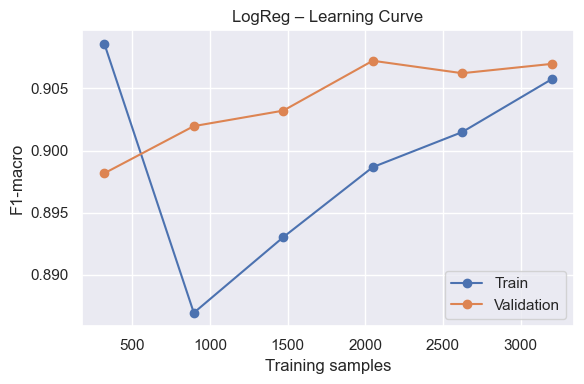

⚠️ 2. Learning Curve Analizi
📌 Train yüksek, Val düşük ve fark büyükse → overfitting.



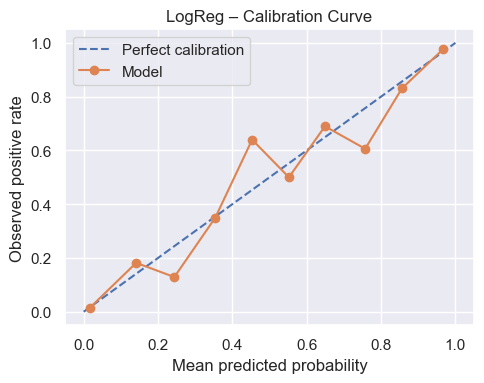

⚠️ 3. Calibration Analizi
ROC-AUC: 0.973
📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.



In [27]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve

# =========================================================
# 0) LOGREG PIPELINE'I KUR (best model değil)
#    preprocess değişkeninin daha önce tanımlı olması lazım.
# =========================================================
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", models["LogReg"])
])
logreg_key = "LogReg"

# =========================================================
# 1) FIT + Report
# =========================================================
logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n📌 {logreg_key} | Test Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

# =========================================================
# 2) F1 GAP
# =========================================================
def f1_gap(model, X_train, y_train, X_test, y_test, threshold=0.08):
    f1_tr = f1_score(y_train, model.predict(X_train), average="macro")
    f1_ts = f1_score(y_test,  model.predict(X_test),  average="macro")
    gap = f1_tr - f1_ts

    print("\n⚠️ 1. Train–Test F1 farkı")
    print(f"Train F1: {f1_tr:.3f}")
    print(f"Test  F1: {f1_ts:.3f}")
    print(f"F1 GAP : {gap:.3f}")

    if gap > threshold:
        print("📌 Yorum: Overfitting sinyali var\n")
    else:
        print("📌 Yorum: Belirgin overfitting yok\n")

# =========================================================
# 3) Learning Curve
# =========================================================
def learning_curve_plot(model, X_train, y_train, title="LogReg – Learning Curve"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    sizes, tr, val = learning_curve(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    plt.figure(figsize=(6,4))
    plt.plot(sizes, tr.mean(axis=1), marker="o", label="Train")
    plt.plot(sizes, val.mean(axis=1), marker="o", label="Validation")
    plt.xlabel("Training samples")
    plt.ylabel("F1-macro")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("⚠️ 2. Learning Curve Analizi")
    print("📌 Train yüksek, Val düşük ve fark büyükse → overfitting.\n")

# =========================================================
# 4) Calibration Curve (binary ise)
# =========================================================
def calibration_curve_plot(model, X_test, y_test, title="LogReg – Calibration Curve"):
    if len(np.unique(y_test)) != 2:
        print("⚠️ Calibration curve sadece binary sınıflandırmada çizilir.")
        return

    if not hasattr(model, "predict_proba"):
        print("⚠️ predict_proba yok → calibration çizilemedi.")
        return

    y_prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")

    plt.figure(figsize=(5,4))
    plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    auc_val = roc_auc_score(y_test, y_prob)
    print("⚠️ 3. Calibration Analizi")
    print(f"ROC-AUC: {auc_val:.3f}")
    print("📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.\n")

# =========================================================
# ÇALIŞTIR
# =========================================================
f1_gap(logreg_pipe, X_train, y_train, X_test, y_test)
learning_curve_plot(logreg_pipe, X_train, y_train)
calibration_curve_plot(logreg_pipe, X_test, y_test)



📌 SVC | Test Accuracy: 0.9040
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       503
           1       0.90      0.90      0.90       497

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


⚠️ 1. Train–Test F1 farkı
Train F1: 0.912
Test  F1: 0.904
F1 GAP : 0.008
📌 Yorum: Belirgin overfitting yok



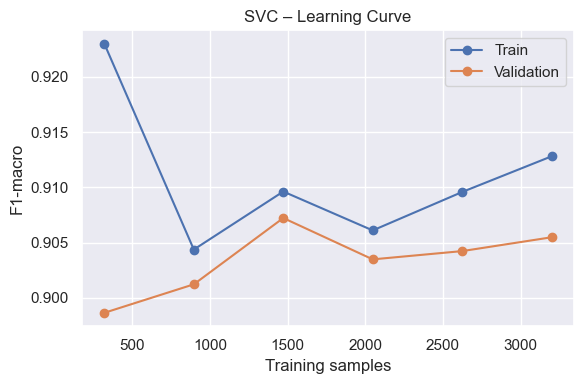

⚠️ 2. Learning Curve Analizi
📌 Train yüksek, Val düşük ve fark büyükse → overfitting.



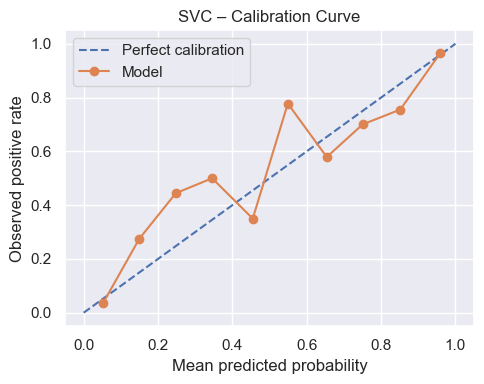

⚠️ 3. Calibration Analizi
ROC-AUC: 0.959
📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.



In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve

# =========================================================
# 0) SVC PIPELINE'I KUR (best model değil)
#    preprocess değişkeninin tanımlı olması lazım.
# =========================================================
svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", models["SVC"])
])
svc_key = "SVC"

# =========================================================
# 1) FIT + Report
# =========================================================
svc_pipe.fit(X_train, y_train)

y_pred = svc_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n📌 {svc_key} | Test Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

# =========================================================
# 2) F1 GAP
# =========================================================
def f1_gap(model, X_train, y_train, X_test, y_test, threshold=0.08):
    f1_tr = f1_score(y_train, model.predict(X_train), average="macro")
    f1_ts = f1_score(y_test,  model.predict(X_test),  average="macro")
    gap = f1_tr - f1_ts

    print("\n⚠️ 1. Train–Test F1 farkı")
    print(f"Train F1: {f1_tr:.3f}")
    print(f"Test  F1: {f1_ts:.3f}")
    print(f"F1 GAP : {gap:.3f}")

    if gap > threshold:
        print("📌 Yorum: Overfitting sinyali var\n")
    else:
        print("📌 Yorum: Belirgin overfitting yok\n")

# =========================================================
# 3) Learning Curve
# =========================================================
def learning_curve_plot(model, X_train, y_train, title="SVC – Learning Curve"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    sizes, tr, val = learning_curve(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    plt.figure(figsize=(6,4))
    plt.plot(sizes, tr.mean(axis=1), marker="o", label="Train")
    plt.plot(sizes, val.mean(axis=1), marker="o", label="Validation")
    plt.xlabel("Training samples")
    plt.ylabel("F1-macro")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("⚠️ 2. Learning Curve Analizi")
    print("📌 Train yüksek, Val düşük ve fark büyükse → overfitting.\n")

# =========================================================
# 4) Calibration Curve (binary ise)
# =========================================================
def calibration_curve_plot(model, X_test, y_test, title="SVC – Calibration Curve"):
    if len(np.unique(y_test)) != 2:
        print("⚠️ Calibration curve sadece binary sınıflandırmada çizilir.")
        return

    # SVC probability=True ise predict_proba var
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # probability=False olsa bile decision_function ile yaklaşık skor
        if not hasattr(model, "decision_function"):
            print("⚠️ predict_proba/decision_function yok → calibration çizilemedi.")
            return
        scores = model.decision_function(X_test)
        # 0-1 aralığına sıkıştırılmış pseudo-prob (kalibrasyon için kaba)
        y_prob = 1 / (1 + np.exp(-scores))

    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")

    plt.figure(figsize=(5,4))
    plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    auc_val = roc_auc_score(y_test, y_prob)
    print("⚠️ 3. Calibration Analizi")
    print(f"ROC-AUC: {auc_val:.3f}")
    print("📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.\n")

# =========================================================
# ÇALIŞTIR
# =========================================================
f1_gap(svc_pipe, X_train, y_train, X_test, y_test)
learning_curve_plot(svc_pipe, X_train, y_train)
calibration_curve_plot(svc_pipe, X_test, y_test)



📌 RF | Test Accuracy: 0.9000
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       503
           1       0.90      0.90      0.90       497

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


⚠️ 1. Train–Test F1 farkı
Train F1: 1.000
Test  F1: 0.900
F1 GAP : 0.100
📌 Yorum: Overfitting sinyali var



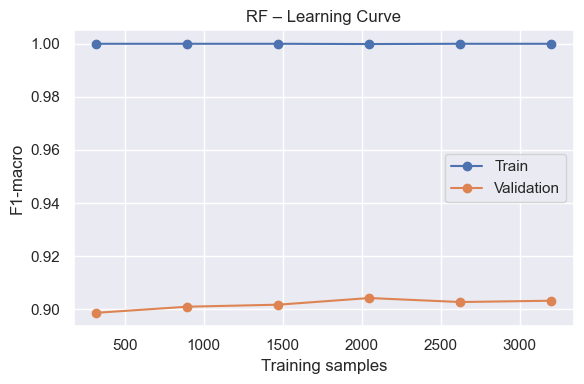

⚠️ 2. Learning Curve Analizi
📌 Train yüksek, Val düşük ve fark büyükse → overfitting.



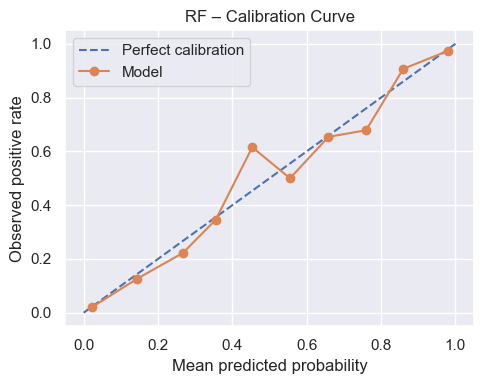

⚠️ 3. Calibration Analizi
ROC-AUC: 0.968
📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.



In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve

# =========================================================
# 0) RF PIPELINE'I KUR (best model değil)
#    preprocess değişkeninin tanımlı olması lazım.
# =========================================================
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", models["RF"])
])
rf_key = "RF"

# =========================================================
# 1) FIT + Report
# =========================================================
rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n📌 {rf_key} | Test Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

# =========================================================
# 2) F1 GAP
# =========================================================
def f1_gap(model, X_train, y_train, X_test, y_test, threshold=0.08):
    f1_tr = f1_score(y_train, model.predict(X_train), average="macro")
    f1_ts = f1_score(y_test,  model.predict(X_test),  average="macro")
    gap = f1_tr - f1_ts

    print("\n⚠️ 1. Train–Test F1 farkı")
    print(f"Train F1: {f1_tr:.3f}")
    print(f"Test  F1: {f1_ts:.3f}")
    print(f"F1 GAP : {gap:.3f}")

    if gap > threshold:
        print("📌 Yorum: Overfitting sinyali var\n")
    else:
        print("📌 Yorum: Belirgin overfitting yok\n")

# =========================================================
# 3) Learning Curve
# =========================================================
def learning_curve_plot(model, X_train, y_train, title="RF – Learning Curve"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    sizes, tr, val = learning_curve(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    plt.figure(figsize=(6,4))
    plt.plot(sizes, tr.mean(axis=1), marker="o", label="Train")
    plt.plot(sizes, val.mean(axis=1), marker="o", label="Validation")
    plt.xlabel("Training samples")
    plt.ylabel("F1-macro")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("⚠️ 2. Learning Curve Analizi")
    print("📌 Train yüksek, Val düşük ve fark büyükse → overfitting.\n")

# =========================================================
# 4) Calibration Curve (binary ise)
# =========================================================
def calibration_curve_plot(model, X_test, y_test, title="RF – Calibration Curve"):
    if len(np.unique(y_test)) != 2:
        print("⚠️ Calibration curve sadece binary sınıflandırmada çizilir.")
        return

    if not hasattr(model, "predict_proba"):
        print("⚠️ predict_proba yok → calibration çizilemedi.")
        return

    y_prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")

    plt.figure(figsize=(5,4))
    plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    auc_val = roc_auc_score(y_test, y_prob)
    print("⚠️ 3. Calibration Analizi")
    print(f"ROC-AUC: {auc_val:.3f}")
    print("📌 Eğri diagonalden sapıyorsa → olasılık tahminleri güvenilir değil.\n")

# =========================================================
# ÇALIŞTIR
# =========================================================
f1_gap(rf_pipe, X_train, y_train, X_test, y_test)
learning_curve_plot(rf_pipe, X_train, y_train)
calibration_curve_plot(rf_pipe, X_test, y_test)


In [30]:
import joblib
from pathlib import Path

# Model
model_to_save = best_models["HGB"]

# Proje kökü = notebook'un çalıştığı yer
BASE_DIR = Path.cwd()

# models klasörü
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Dosya yolu
MODEL_PATH = MODEL_DIR / "hgb_pipeline.joblib"

# Kaydet
joblib.dump(model_to_save, MODEL_PATH)

print("✅ Model kaydedildi")
print("📄 Yol:", MODEL_PATH.resolve())


✅ Model kaydedildi
📄 Yol: /Users/betulbostan/Desktop/teknoloji_ruh_sagligi/models/hgb_pipeline.joblib


In [31]:
import sklearn, sys
print("python:", sys.version)
print("sklearn:", sklearn.__version__)


python: 3.11.7 (main, Dec 15 2023, 12:09:04) [Clang 14.0.6 ]
sklearn: 1.2.2
